# Data Mining Project Template (GitHub + Colab)
## Dominic Rueck
## 04/10/2026
## Ethereum Fraud Detection

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

# Project Overview

## 1. Introduction and Problem Statement
As blockchain technology gains mainstream adoption, the Ethereum network has become a primary hub for global decentralized finance. However, as with all financial systems, people try to exploit vulnerabilities for fraudulent gain. Detecting and preventing fraud on the Ethereum blockchain is crucial for maintaining trust and security in the ecosystem.

The core objective of this project is to build a robust classification model capable of differentiating between valid and fraudulent transactions on the Ethereum blockchain. By leveraging historical transaction patterns, I aim to predict the likelihood of fraud, specifically targeting the FLAG variable within our dataset.

## 2. Business Use Case and Impact
This tool could serve as a critical tool for:
- **Financial Institutions & Exchanges**: To automatically flag suspicious transactions or wallets and to protect users from potential losses.
- **Regulatory Bodies**: To monitor and investigate fraudulent activities on the blockchain, ensuring compliance with financial regulations.
- **Individual Users**: To safeguard their assets by identifying potentially fraudulent transactions before they occur.

## 3. Data Acquisition
The data used in this project is sourced from Kaggle, specifically from the <a href="https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset">Ethereum Transaction Dataset for Fraud Detection</a>. This dataset contains a comprehensive collection of Ethereum transactions, labeled as either valid or fraudulent, along with various features that describe the transaction details.

## Motivation
I selected this dataset and problem because of the growing importance of blockchain technology and the critical need for security in decentralized finance. Fraud detection on the Ethereum network is a real-world problem with significant implications for users and institutions alike. By applying data mining techniques to this dataset, I hope to contribute to the development of more secure blockchain systems and to gain practical experience in handling complex, real-world data.



## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


In [2]:
data_path = "transaction_dataset.csv"
df = pd.read_csv(data_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [3]:
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [4]:
# Basic data inspection
print("Shape (rows, columns):", df.shape)
print("\nColumn dtypes (counts):")
print(df.dtypes.value_counts())

id_like = ["Unnamed: 0", "Index", "Address"]
for c in id_like:
    if c in df.columns:
        print(f"  {c}: nunique = {df[c].nunique(dropna=False):,} (rows {len(df):,})")

dup_rows = df.duplicated().sum()
print(f"\nFully duplicate rows: {dup_rows}")

display(df.head())
df.info()
display(df.describe(include="all").T)



Shape (rows, columns): (9841, 51)

Column dtypes (counts):
float64    39
int64       9
object      3
Name: count, dtype: int64
  Unnamed: 0: nunique = 9,841 (rows 9,841)
  Index: nunique = 4,729 (rows 9,841)
  Address: nunique = 9,816 (rows 9,841)

Fully duplicate rows: 0


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,NaN,NaN,NaN,4920.0,2840.996333,0.0,2460.0,4920.0,7380.0,9840.0
Index,9841.0,NaN,NaN,NaN,1815.049893,1222.62183,1.0,821.0,1641.0,2601.0,4729.0
Address,9841,9816,0x4cd526aa2db72eb1fd557b37c6b0394acd35b212,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG,9841.0,NaN,NaN,NaN,0.221421,0.415224,0.0,0.0,0.0,0.0,1.0
Avg min between sent tnx,9841.0,NaN,NaN,NaN,5086.878721,21486.549974,0.0,0.0,17.34,565.47,430287.67
Avg min between received tnx,9841.0,NaN,NaN,NaN,8004.851184,23081.714801,0.0,0.0,509.77,5480.39,482175.49
Time Diff between first and last (Mins),9841.0,NaN,NaN,NaN,218333.257652,322937.92574,0.0,316.93,46637.03,304070.98,1954860.95
Sent tnx,9841.0,NaN,NaN,NaN,115.931714,757.226361,0.0,1.0,3.0,11.0,10000.0
Received Tnx,9841.0,NaN,NaN,NaN,163.700945,940.83655,0.0,1.0,4.0,27.0,10000.0
Number of Created Contracts,9841.0,NaN,NaN,NaN,3.729702,141.445583,0.0,0.0,0.0,0.0,9995.0


,missing_n,missing_pct
ERC20 most sent token type,2697,27.41
ERC20_most_rec_token_type,871,8.85
ERC20 min val rec,829,8.42
ERC20 total ether sent,829,8.42
ERC20 total Ether sent contract,829,8.42
ERC20 uniq sent addr,829,8.42
ERC20 uniq rec addr,829,8.42
ERC20 uniq sent addr.1,829,8.42
ERC20 uniq rec contract addr,829,8.42
ERC20 avg time between sent tnx,829,8.42


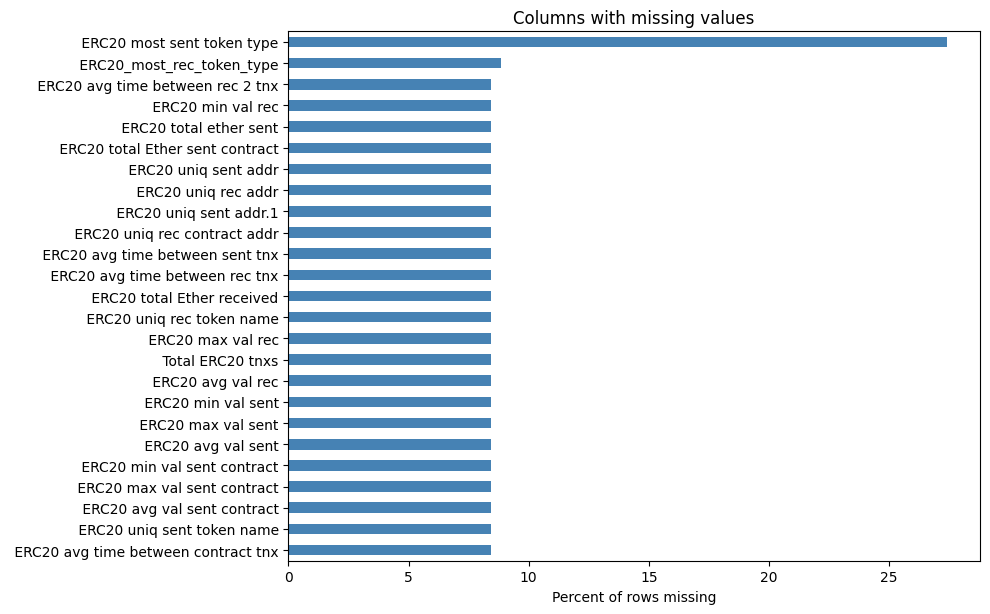

In [5]:
# Missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing_n": missing_counts, "missing_pct": missing_pct})
display(missing_tbl)

if len(missing_tbl) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Percent of rows missing")
    ax.set_title("Columns with missing values")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")



In [6]:
# Target variable (wallet fraud label)
target = "FLAG"

vc = df[target].value_counts(dropna=False)
prop = df[target].value_counts(normalize=True, dropna=False)
display(vc)
display(prop)

maj_n, min_n = int(vc.max()), int(vc.min())
imb_ratio = maj_n / min_n if min_n else float("nan")
print(f"Imbalance ratio (majority / minority): {imb_ratio:.2f}:1")
print(f"Minority class share: {prop.get(1, prop.get('1', float('nan'))):.2%}")



FLAG
0    7662
1    2179
Name: count, dtype: int64

FLAG
0    0.778579
1    0.221421
Name: proportion, dtype: float64

Imbalance ratio (majority / minority): 3.52:1
Minority class share: 22.14%


The target `FLAG` is **imbalanced**: legitimate-labeled rows are the majority and fraud is the minority (about **22%** fraud in this file, or roughly **3.5:1** majority-to-minority). Accuracy alone can look optimistic while missing fraud, so later modeling emphasizes **precision, recall, F1, and Cohen's kappa**, and we can add class weights or resampling if needed.

Most missingness is concentrated in **ERC-20–related** columns (wallets with no token activity). Those gaps are handled in the modeling pipeline with **imputation** rather than dropping rows, so we keep all labeled addresses.



## Data Visualization

### Class balance and distribution of the target variable

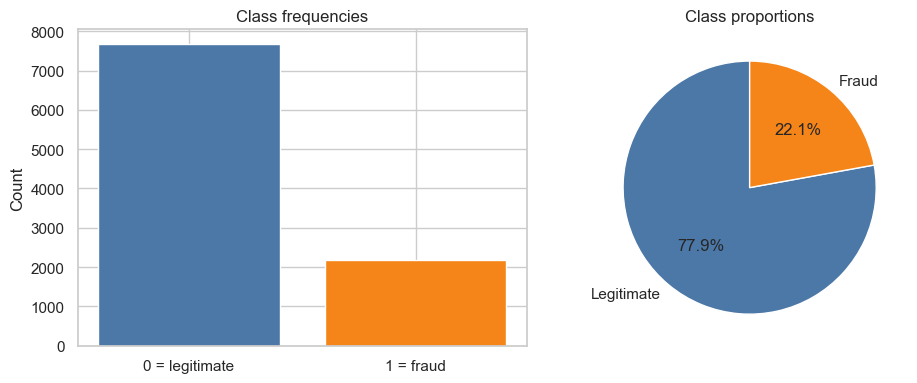

In [7]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc = df[target].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=["#4C78A8", "#F58518"])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0 = legitimate", "1 = fraud"])
axes[0].set_ylabel("Count")
axes[0].set_title("Class frequencies")

axes[1].pie(
    vc.values,
    labels=["Legitimate", "Fraud"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518"],
)
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.show()

### Numeric features only (exclude target); correlations with FLAG

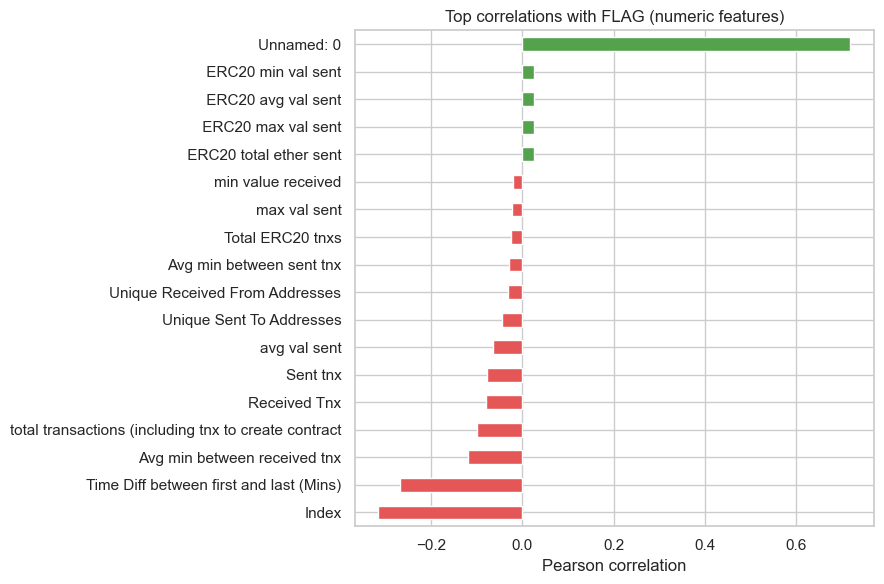

In [8]:
num_df = df.select_dtypes(include="number").copy()
if target in num_df.columns:
    corr_flag = num_df.corr()[target].drop(labels=[target], errors="ignore")
    corr_flag = corr_flag.dropna()
    corr_flag = corr_flag.loc[corr_flag.abs().sort_values(ascending=False).index].head(18)

    fig, ax = plt.subplots(figsize=(9, 6))
    corr_flag.sort_values().plot(kind="barh", ax=ax, color=np.where(corr_flag.sort_values() < 0, "#E45756", "#54A24B"))
    ax.set_title("Top correlations with FLAG (numeric features)")
    ax.set_xlabel("Pearson correlation")
    plt.tight_layout()
    plt.show()

### Check correlation between all the features

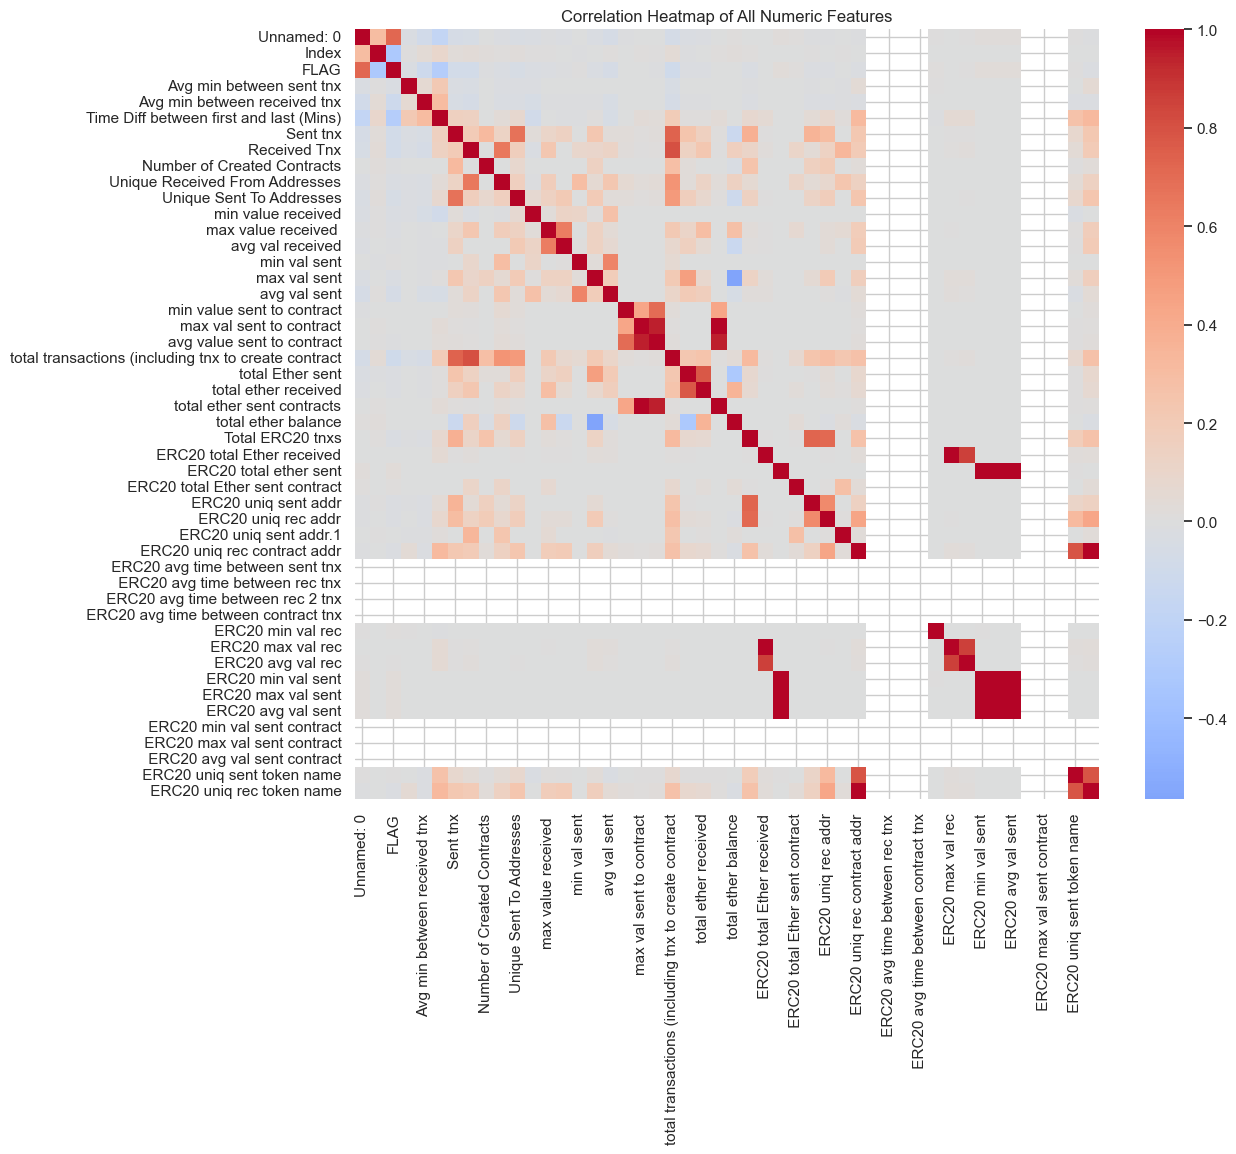

In [9]:

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of All Numeric Features")
plt.show()

## Outlier Visualization

### We remove the identifier columns as they are not useful for modeling but might have a correlation with the target variable and would therefore mess with the next plots and with the model

In [10]:
_drop = [c for c in ["Unnamed: 0", "Index", "Address"] if c in df.columns]
if _drop:
    df = df.drop(columns=_drop)
    print("Dropped columns:", _drop)
else:
    print("No identifier columns found to drop (already removed).")
print("Shape after dropping identifiers:", df.shape)

Dropped columns: ['Unnamed: 0', 'Index', 'Address']
Shape after dropping identifiers: (9841, 48)


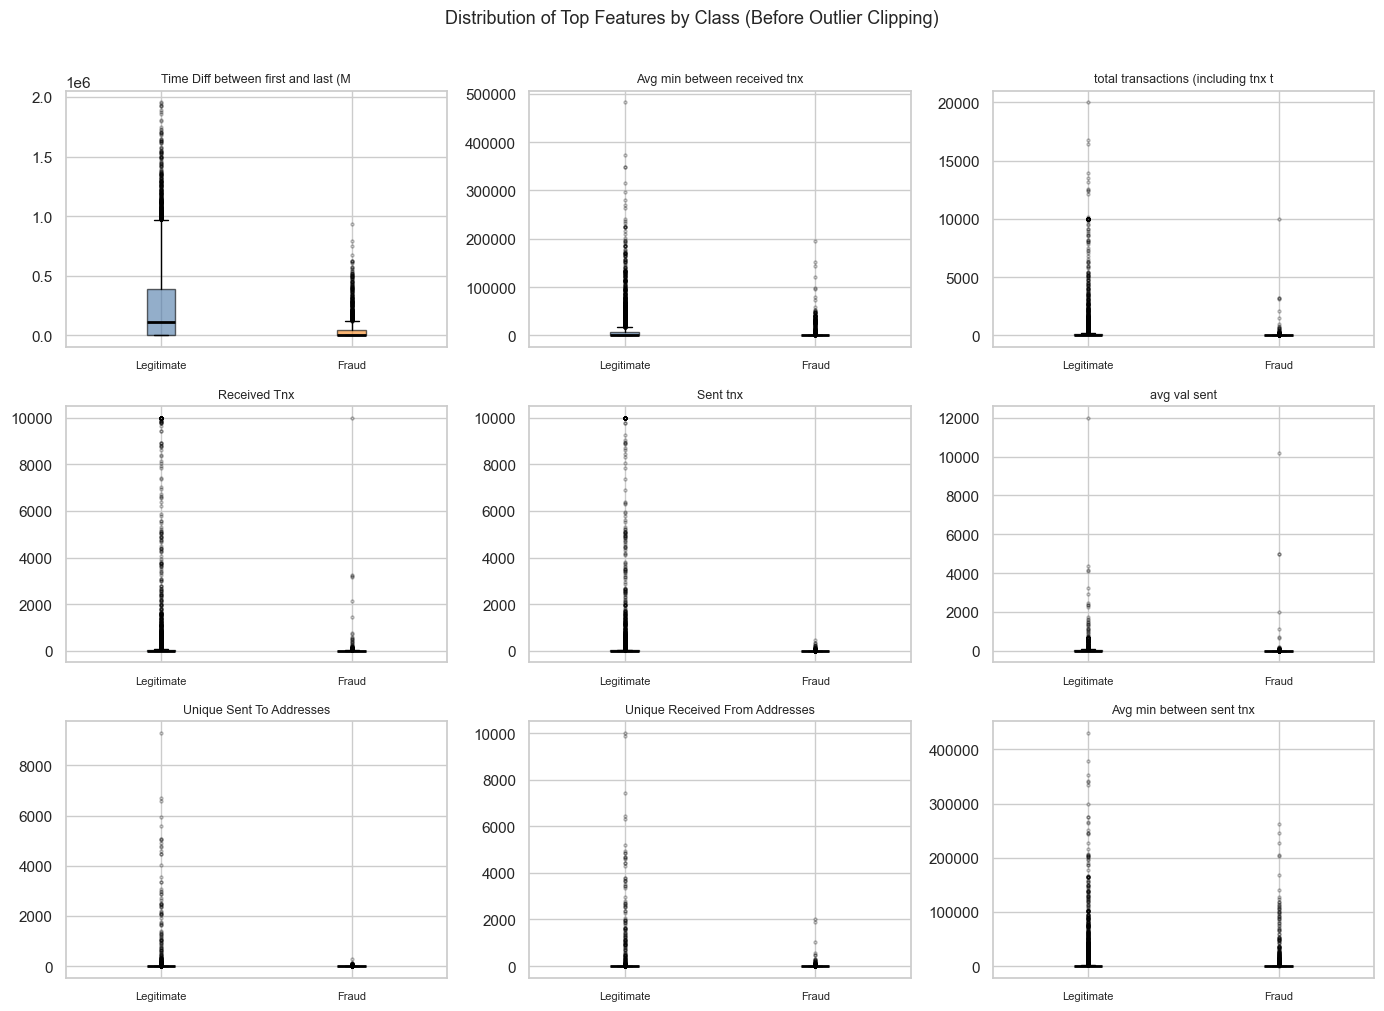

Blue = Legitimate  |  Orange = Fraud


In [11]:
num_df_raw = df.select_dtypes(include='number').copy()
if target in num_df_raw.columns:
    top_corr_cols = (
        num_df_raw.corr()[target]
        .drop(labels=[target], errors='ignore')
        .abs()
        .sort_values(ascending=False)
        .head(9)
        .index.tolist()
    )

    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_corr_cols):
        axes[i].boxplot(
            [num_df_raw.loc[num_df_raw[target] == 0, col].dropna(),
             num_df_raw.loc[num_df_raw[target] == 1, col].dropna()],
            labels=['Legitimate', 'Fraud'],
            patch_artist=True,
            boxprops=dict(facecolor='#4C78A8', alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3)
        )
        # Color fraud boxes differently
        boxes = axes[i].findobj(plt.matplotlib.patches.PathPatch)
        if len(boxes) > 1:
            boxes[1].set_facecolor('#F58518')
        axes[i].set_title(col[:35], fontsize=9)
        axes[i].tick_params(axis='x', labelsize=8)

    plt.suptitle('Distribution of Top Features by Class (Before Outlier Clipping)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print('Blue = Legitimate  |  Orange = Fraud')


## Histograms for top 9 features, overlaid by class

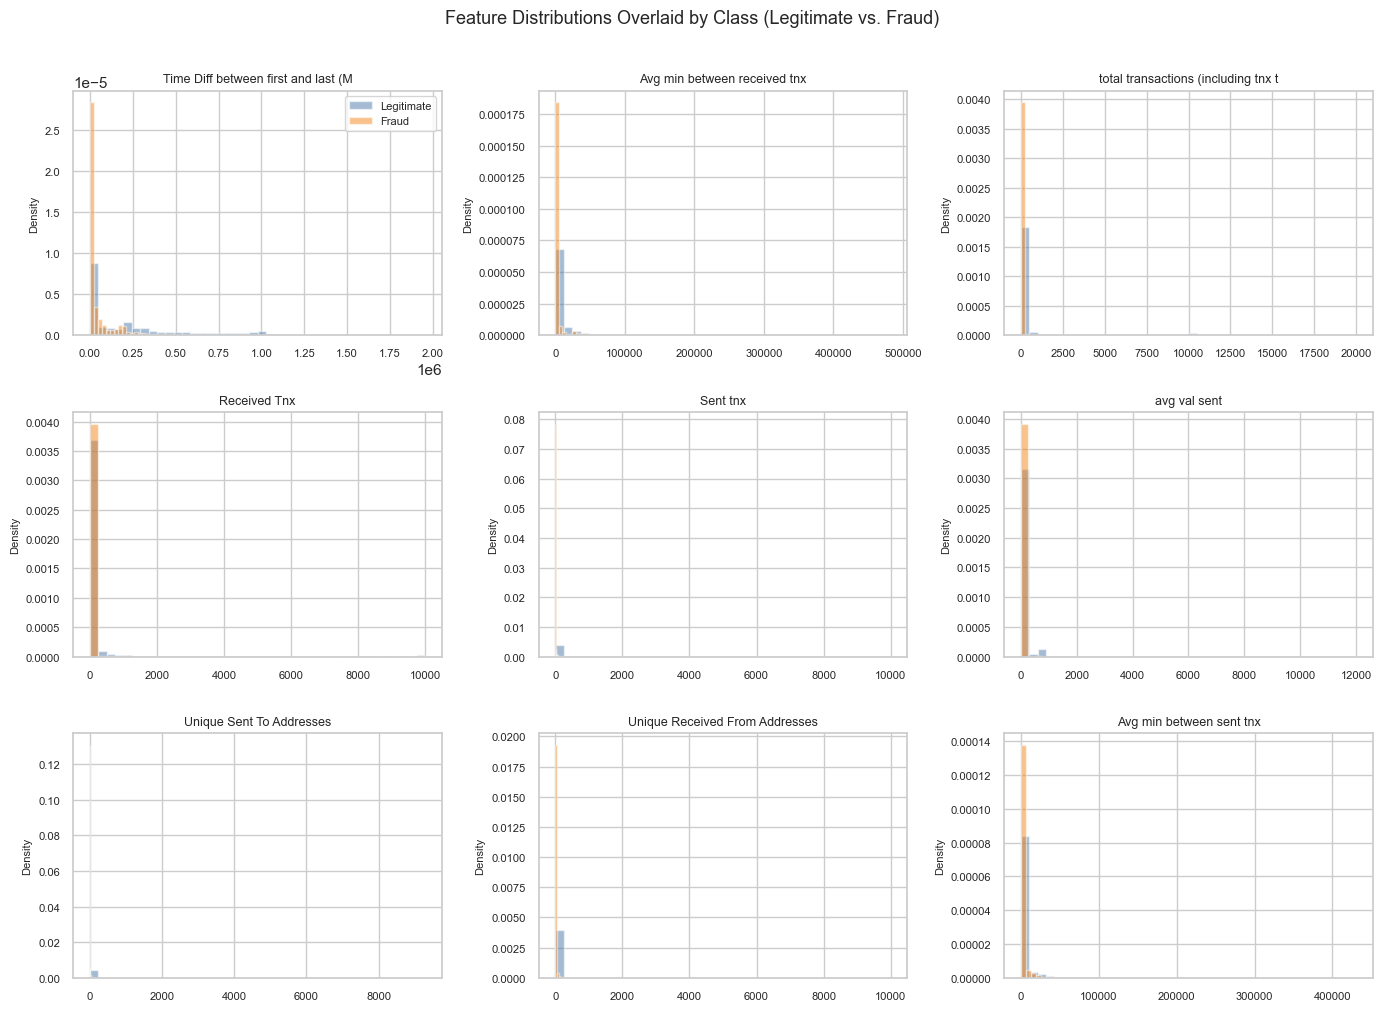

Overlap = similar behavior between classes  |  Separation = strong predictive signal


In [12]:
# Histograms for top 9 features, overlaid by class
if target in df.select_dtypes(include='number').columns:
    top_hist_cols = (
        df.select_dtypes(include='number')
        .corr()[target]
        .drop(labels=[target], errors='ignore')
        .abs()
        .sort_values(ascending=False)
        .head(9)
        .index.tolist()
    )

    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_hist_cols):
        for label, color, name in [(0, '#4C78A8', 'Legitimate'), (1, '#F58518', 'Fraud')]:
            vals = df.loc[df[target] == label, col].dropna()
            axes[i].hist(vals, bins=40, alpha=0.5, color=color, label=name, density=True)
        axes[i].set_title(col[:35], fontsize=9)
        axes[i].set_ylabel('Density', fontsize=8)
        axes[i].tick_params(labelsize=8)
        if i == 0:
            axes[i].legend(fontsize=8)

    plt.suptitle('Feature Distributions Overlaid by Class (Legitimate vs. Fraud)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print('Overlap = similar behavior between classes  |  Separation = strong predictive signal')


## Feature Distribution by class


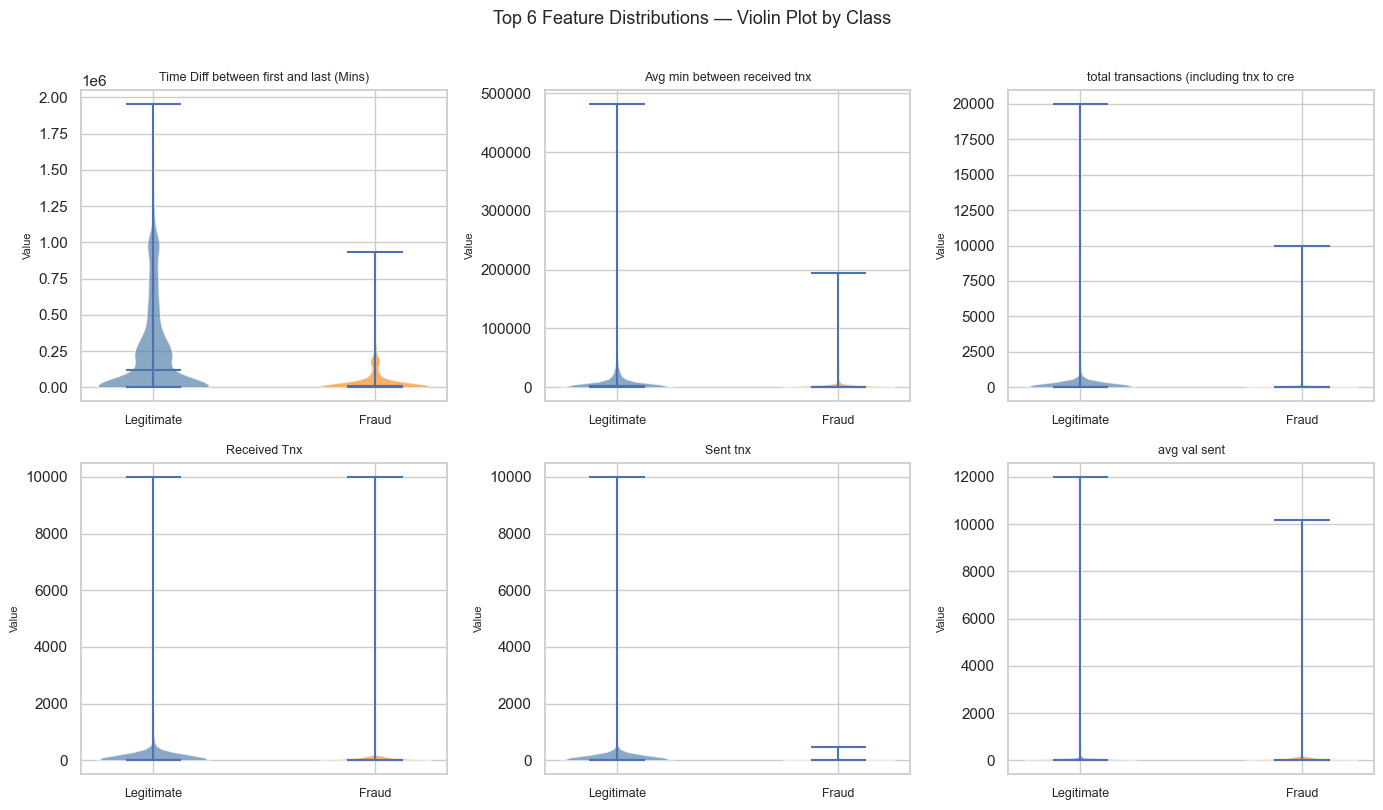

In [13]:
# Violin plots — top 6 features by correlation with FLAG
if target in df.select_dtypes(include='number').columns:
    top_viol_cols = (
        df.select_dtypes(include='number')
        .corr()[target]
        .drop(labels=[target], errors='ignore')
        .abs()
        .sort_values(ascending=False)
        .head(6)
        .index.tolist()
    )

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(top_viol_cols):
        data_leg  = df.loc[df[target] == 0, col].dropna()
        data_fraud = df.loc[df[target] == 1, col].dropna()

        parts = axes[i].violinplot(
            [data_leg, data_fraud],
            positions=[0, 1],
            showmedians=True,
            showextrema=True
        )
        colors = ['#4C78A8', '#F58518']
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[j])
            pc.set_alpha(0.65)

        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Legitimate', 'Fraud'], fontsize=9)
        axes[i].set_title(col[:40], fontsize=9)
        axes[i].set_ylabel('Value', fontsize=8)

    plt.suptitle('Top 6 Feature Distributions — Violin Plot by Class', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


### Data preparation summary

- **Identifiers removed**: `Unnamed: 0`, `Index`, and `Address` were dropped so the model does not use row keys or raw wallet strings (high cardinality, weak legitimate signal for this pipeline).

- **Missing values**: ERC-20 and related fields are often empty when a wallet has no token activity. All rows are kept. **Numeric** columns are filled with the **column median**, and **categorical** columns with the **mode** (or the literal `(missing)` if a column were entirely empty). The sklearn pipeline in the next section still includes imputers so the same modeling code stays valid if anything remains.

- **Outliers**: Extreme values on **numeric feature** columns (not `FLAG`) are **soft-capped** using the **1.5×IQR** rule; when the IQR is zero (near-constant column), values are clipped to the **1st–99th percentiles** instead. This reduces the pull of extreme sends/receives/timing without deleting rare fraud rows.

- **Train / test split**: A **stratified 80/20** split (`random_state=123`) keeps a similar fraud rate in train and test.

- **Feature engineering**: No new derived columns in this milestone; behavior comes from the existing aggregates after cleaning.


## Handle missing values

In [14]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != target]
cat_cols = [c for c in df.select_dtypes(include=["object", "category", "bool"]).columns]

missing_cells_before = df[num_cols + cat_cols].isna().sum().sum()

for col in num_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)

for col in cat_cols:
    if df[col].isna().all():
        df[col] = "(missing)"
    else:
        mode_val = df[col].mode(dropna=True)
        fill = mode_val.iloc[0] if len(mode_val) else "(missing)"
        df[col] = df[col].fillna(fill)

missing_cells_after = df[num_cols + cat_cols].isna().sum().sum()
print(f"Missing value cells (features only): {int(missing_cells_before):,} -> {int(missing_cells_after):,}")



Missing value cells (features only): 22,635 -> 0


## Outlier handling

In [15]:
K_IQR = 1.5
total_clipped = 0
skipped = []

for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            skipped.append(col)
            continue
    else:
        lo, hi = q1 - K_IQR * iqr, q3 + K_IQR * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    total_clipped += n_out
    df[col] = s.clip(lower=lo, upper=hi)

print(f"Numeric outlier treatments: clipped {total_clipped:,} cell values across {len(num_cols)} columns (IQR with percentile fallback).")
if skipped:
    print("Skipped (constant / degenerate):", skipped[:8], "..." if len(skipped) > 8 else "")

print("Final shape:", df.shape)


Numeric outlier treatments: clipped 39,133 cell values across 45 columns (IQR with percentile fallback).
Skipped (constant / degenerate): ['min value sent to contract', 'max val sent to contract', 'avg value sent to contract', 'total ether sent contracts', ' ERC20 total Ether sent contract', ' ERC20 uniq sent addr.1', ' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx'] ...
Final shape: (9841, 48)


## Take care of features with a variance of 0

In [16]:
# Check for zero-variance features
zero_var_cols = [col for col in num_cols if df[col].nunique() <= 1]
if zero_var_cols:
    df = df.drop(columns=zero_var_cols)
    print(f"Dropped {len(zero_var_cols)} zero-variance numeric columns:", zero_var_cols[:8], "..." if len(zero_var_cols) > 8 else "")
else:
    print("No zero-variance numeric features detected.")

Dropped 7 zero-variance numeric columns: [' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx', ' ERC20 avg time between rec 2 tnx', ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract', ' ERC20 max val sent contract', ' ERC20 avg val sent contract'] 


In [17]:
#ERC20 most sent token type and ERC20_most_rec_token_type are of type object but have very high cardinality (over 100 unique values each) and are unlikely to be useful for modeling, so we will drop them.
drop_cols = []
for col in ["ERC20 most sent token type", "ERC20_most_rec_token_type"]:
    if col in df.columns:
        drop_cols.append(col)

## Display the cleaned dataframe info and head after preparation steps

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 41 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg min between sent tnx                              9841 non-null   float64
 2   Avg min between received tnx                          9841 non-null   float64
 3   Time Diff between first and last (Mins)               9841 non-null   float64
 4   Sent tnx                                              9841 non-null   int64  
 5   Received Tnx                                          9841 non-null   int64  
 6   Number of Created Contracts                           9841 non-null   int64  
 7   Unique Received From Addresses                        9841 non-null   int64  
 8   Unique Sent To Addresses                              9841

In [19]:
df.head()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,844.260,1093.710,704785.630,26,66,0,11,6,0.000000,...,0.0,47.513982,33.425,0.000000,2.913074e+06,159706.479300,30.0,5.0,Cofoundit,Numeraire
1,0,1413.675,2958.440,759702.055,26,8,0,5,6,0.000000,...,0.0,47.513982,33.425,2.260809,2.260809e+00,2.260809,1.0,5.0,Livepeer Token,Livepeer Token
2,0,1413.675,2434.020,516729.300,2,10,0,10,2,0.113119,...,0.0,47.513982,33.425,0.000000,0.000000e+00,0.000000,0.0,5.0,0,XENON
3,0,1413.675,13700.975,397555.900,25,9,0,7,6,0.000000,...,0.0,47.513982,33.425,100.000000,9.029231e+03,3804.076893,1.0,5.0,Raiden,XENON
4,0,36.610,10707.770,382472.420,26,20,1,7,6,0.000000,...,0.0,47.513982,33.425,0.000000,4.500000e+04,13726.659220,6.0,5.0,StatusNetwork,EOS


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FLAG,9841.0,NaN,NaN,NaN,0.221421,0.415224,0.0,0.0,0.0,0.0,1.0
Avg min between sent tnx,9841.0,NaN,NaN,NaN,370.353484,577.869376,0.0,0.0,17.34,565.47,1413.675
Avg min between received tnx,9841.0,NaN,NaN,NaN,3498.283942,4999.682546,0.0,0.0,509.77,5480.39,13700.975
Time Diff between first and last (Mins),9841.0,NaN,NaN,NaN,193507.506975,257307.392433,0.0,316.93,46637.03,304070.98,759702.055
Sent tnx,9841.0,NaN,NaN,NaN,7.391119,9.591481,0.0,1.0,3.0,11.0,26.0
Received Tnx,9841.0,NaN,NaN,NaN,18.232598,24.513922,0.0,1.0,4.0,27.0,66.0
Number of Created Contracts,9841.0,NaN,NaN,NaN,0.137791,0.344698,0.0,0.0,0.0,0.0,1.0
Unique Received From Addresses,9841.0,NaN,NaN,NaN,3.744233,3.437438,0.0,1.0,2.0,5.0,11.0
Unique Sent To Addresses,9841.0,NaN,NaN,NaN,2.268773,2.047011,0.0,1.0,2.0,3.0,6.0
min value received,9841.0,NaN,NaN,NaN,1.32791,2.026014,0.0,0.001,0.095856,2.0,4.9985


# Predicting Fraud

In [21]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)


## Prepare Features and Train/Test Split

In [21]:
# Drop high-cardinality token-type columns if still present
for col in ['ERC20 most sent token type', 'ERC20_most_rec_token_type']:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'Dropped high-cardinality column: {col}')

X = df.drop(columns=[target])
y = df[target]

categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()

print(f'Features: {X.shape[1]} columns  |  Rows: {X.shape[0]}')
print(f'  Numeric   : {len(numeric_cols)}')
print(f'  Categorical: {len(categorical_cols)}')
print(f'Target distribution:\n{y.value_counts(normalize=True).round(3)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)
print(f'\nTrain size: {len(X_train):,}  |  Test size: {len(X_test):,}')


Features: 40 columns  |  Rows: 9841
  Numeric   : 38
  Categorical: 2
Target distribution:
FLAG
0    0.779
1    0.221
Name: proportion, dtype: float64

Train size: 7,872  |  Test size: 1,969


## Handle Class Imbalance With Training-Only Oversampling

The target variable is imbalanced, so the model may learn the majority class more easily than the fraud class. To reduce that risk, the next cell oversamples the minority class in the training data only. The test set stays unchanged so the final evaluation still reflects the original real-world class distribution.

In [22]:
from sklearn.utils import resample

train_data = X_train.copy()
train_data[target] = y_train.values

class_counts = train_data[target].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_data = train_data[train_data[target] == majority_class]
minority_data = train_data[train_data[target] == minority_class]

minority_oversampled = resample(
    minority_data,
    replace=True,
    n_samples=len(majority_data),
    random_state=123
)

train_balanced = pd.concat([majority_data, minority_oversampled], axis=0)
train_balanced = train_balanced.sample(frac=1, random_state=123).reset_index(drop=True)

X_train_balanced = train_balanced.drop(columns=[target])
y_train_balanced = train_balanced[target]

print('Original training distribution:')
print(y_train.value_counts())
print('\nBalanced training distribution after oversampling:')
print(y_train_balanced.value_counts())
print('\nBalanced training distribution (%):')
print(y_train_balanced.value_counts(normalize=True).round(3))

Original training distribution:
FLAG
0    6129
1    1743
Name: count, dtype: int64

Balanced training distribution after oversampling:
FLAG
1    6129
0    6129
Name: count, dtype: int64

Balanced training distribution (%):
FLAG
1    0.5
0    0.5
Name: proportion, dtype: float64


## Build Preprocessing Pipeline

In [23]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Baseline Random Forest model

In [25]:
from sklearn.metrics import roc_auc_score

rf_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=123, max_depth=5))
])

rf_baseline.fit(X_train_balanced, y_train_balanced)
y_pred_baseline = rf_baseline.predict(X_test)

print('=== Baseline Random Forest with Oversampling ===')
print(classification_report(y_test, y_pred_baseline, target_names=['Legitimate', 'Fraud']))
kappa_baseline = cohen_kappa_score(y_test, y_pred_baseline)
print(f"Cohen's Kappa : {kappa_baseline:.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, rf_baseline.predict_proba(X_test)[:,1]):.4f}")


=== Baseline Random Forest with Oversampling ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      1533
       Fraud       0.89      0.96      0.92       436

    accuracy                           0.96      1969
   macro avg       0.94      0.96      0.95      1969
weighted avg       0.97      0.96      0.96      1969

Cohen's Kappa : 0.8997
ROC-AUC       : 0.9940


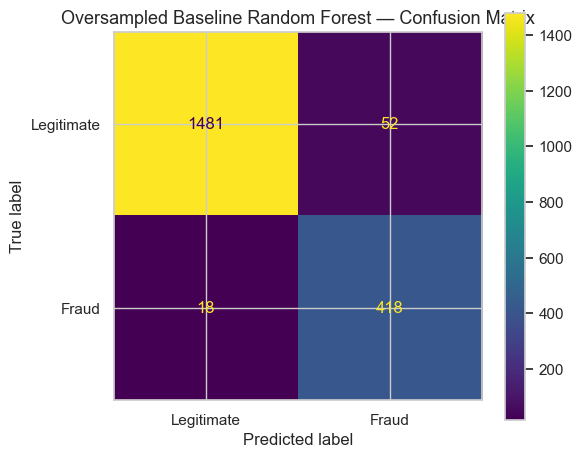

In [26]:
# Confusion matrix
import matplotlib.pyplot as plt

# Confusion matrix — oversampled baseline RF
plt.close('all')
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_baseline),
    display_labels=['Legitimate', 'Fraud']
).plot(ax=ax, colorbar=True)
ax.set_title('Oversampled Baseline Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


## This model already is performing well, but we can still try to improve it.

## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [27]:
# Hyperparameter tuning — GridSearchCV on the oversampled training set
param_grid = {
    'model__n_estimators'    : [100, 200],
    'model__max_depth'       : [5, 7, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf' : [1, 2],
    'model__class_weight'     : [None, 'balanced']  # additional imbalance-aware option
}

rf_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # focuses model selection on the fraud class, where label 1 = fraud
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)
best_rf = grid_search.best_estimator_

print('\nBest Parameters Found:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV F1 for Fraud Class: {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 48 candidates, totalling 240 fits



Best Parameters Found:
  model__class_weight: balanced
  model__max_depth: 10
  model__min_samples_leaf: 1
  model__min_samples_split: 2
  model__n_estimators: 100

Best CV F1 for Fraud Class: 0.9903


In [28]:
# Tuned RF evaluation on the original held-out test set
best_preds = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:, 1]

print('=== Tuned Random Forest with Oversampling (Best from GridSearchCV) ===')
print(classification_report(y_test, best_preds, target_names=['Legitimate', 'Fraud']))
kappa_tuned = cohen_kappa_score(y_test, best_preds)
auc_tuned   = roc_auc_score(y_test, best_proba)
print(f"Cohen's Kappa : {kappa_tuned:.4f}")
print(f"ROC-AUC       : {auc_tuned:.4f}")

=== Tuned Random Forest with Oversampling (Best from GridSearchCV) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1533
       Fraud       0.98      0.96      0.97       436

    accuracy                           0.99      1969
   macro avg       0.98      0.98      0.98      1969
weighted avg       0.99      0.99      0.99      1969

Cohen's Kappa : 0.9614
ROC-AUC       : 0.9988


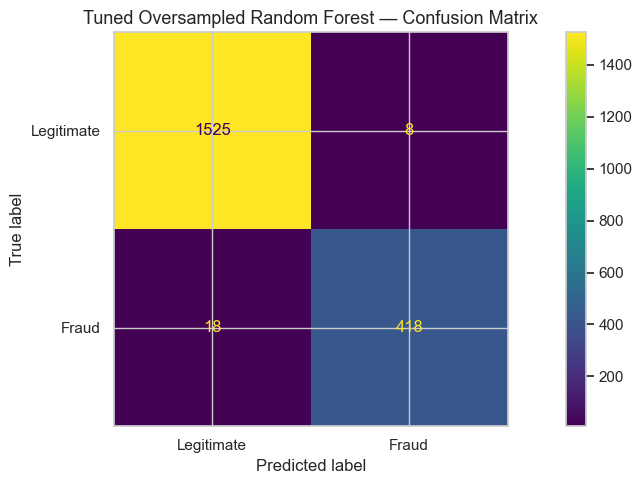

In [29]:
# Tuned RF confusion matrix
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best_preds),
    display_labels=['Legitimate', 'Fraud']
).plot(ax=ax, colorbar=True)
ax.set_title('Tuned Oversampled Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'True Positive Rate')

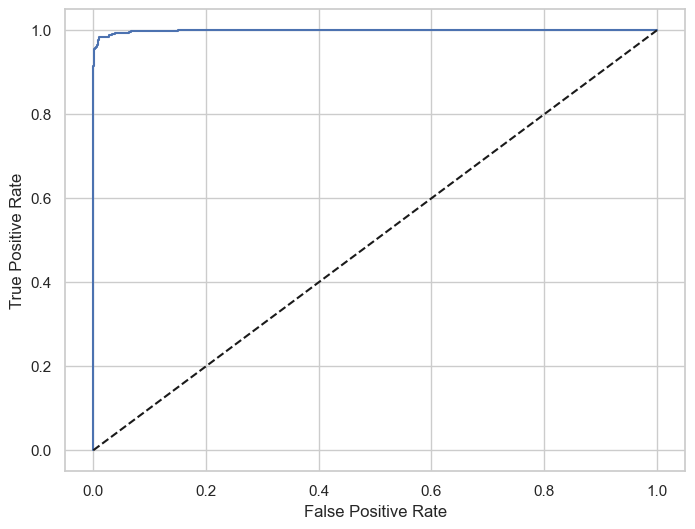

In [30]:
## plot the roc curve
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, best_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(auc_tuned))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

## Comparison model: Gradient Boosting

**Gradient Boosting** is another ensemble of decision trees, but trees are built **sequentially** (each new tree tries to correct the errors of the previous ones), unlike **Random Forest**, where trees are trained **in parallel** on random subsamples. Both use the same preprocessing pipeline and the same **oversampled training data**, so metrics on the held-out test set are comparable.

The next cell runs **`GridSearchCV`** with **`f1`** scoring (fraud as the positive class), matching the tuned Random Forest setup.


In [31]:
# Tuned Gradient Boosting — same preprocessor + balanced training set
gbm_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=123))
])

gbm_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__min_samples_leaf': [1, 2],
}

gbm_grid_search = GridSearchCV(
    estimator=gbm_tuning_pipeline,
    param_grid=gbm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gbm_grid_search.fit(X_train_balanced, y_train_balanced)
best_gbm = gbm_grid_search.best_estimator_

gbm_preds = best_gbm.predict(X_test)
gbm_proba = best_gbm.predict_proba(X_test)[:, 1]

print('=== Tuned Gradient Boosting (Best from GridSearchCV) ===')
print('Best parameters:')
for k, v in gbm_grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f"Best CV F1 (fraud): {gbm_grid_search.best_score_:.4f}\n")
print(classification_report(y_test, gbm_preds, target_names=['Legitimate', 'Fraud']))
kappa_gbm = cohen_kappa_score(y_test, gbm_preds)
auc_gbm = roc_auc_score(y_test, gbm_proba)
print(f"Cohen's Kappa : {kappa_gbm:.4f}")
print(f"ROC-AUC       : {auc_gbm:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== Tuned Gradient Boosting (Best from GridSearchCV) ===
Best parameters:
  model__learning_rate: 0.1
  model__max_depth: 5
  model__min_samples_leaf: 2
  model__n_estimators: 200
Best CV F1 (fraud): 0.9977

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      1533
       Fraud       1.00      0.98      0.99       436

    accuracy                           0.99      1969
   macro avg       0.99      0.99      0.99      1969
weighted avg       0.99      0.99      0.99      1969

Cohen's Kappa : 0.9837
ROC-AUC       : 0.9995


In [32]:
# Compare to tuned Random Forest (same test set; variables from earlier cells)
f1_rf_fraud = f1_score(y_test, best_preds, pos_label=1)
f1_gbm_fraud = f1_score(y_test, gbm_preds, pos_label=1)
print('\n--- Test-set comparison (fraud = positive class) ---')
print(f"Random Forest   : F1-fraud={f1_rf_fraud:.4f}  Kappa={kappa_tuned:.4f}  ROC-AUC={auc_tuned:.4f}")
print(f"Gradient Boosting: F1-fraud={f1_gbm_fraud:.4f}  Kappa={kappa_gbm:.4f}  ROC-AUC={auc_gbm:.4f}")


--- Test-set comparison (fraud = positive class) ---
Random Forest   : F1-fraud=0.9698  Kappa=0.9614  ROC-AUC=0.9988
Gradient Boosting: F1-fraud=0.9873  Kappa=0.9837  ROC-AUC=0.9995


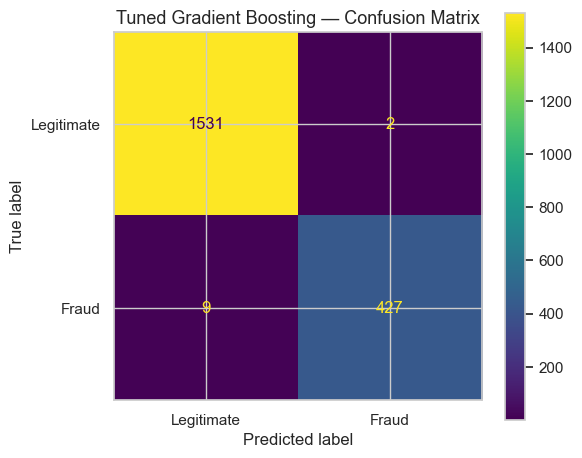

In [33]:
plt.close('all')
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, gbm_preds),
    display_labels=['Legitimate', 'Fraud']
).plot(ax=ax, colorbar=True)
ax.set_title('Tuned Gradient Boosting — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

**But**:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


In [34]:
# Feature importance from the tuned Random Forest
feature_names  = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances    = best_rf.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\
    .sort_values('importance', ascending=False)

# Clean up sklearn prefix (num__, cat__)
feat_imp_df['feature_clean'] = feat_imp_df['feature']\
    .str.replace(r'^(num__|cat__)', '', regex=True)

print('Top 15 most important features:')
display(feat_imp_df[['feature_clean', 'importance']].head(15).reset_index(drop=True))

# Grouped importance (sum across one-hot encoded dummies of same original column)
feat_imp_df['base_feature'] = feat_imp_df['feature_clean'].str.split('_').str[0]
grouped_imp = feat_imp_df.groupby('base_feature')['importance'].sum()\
    .sort_values(ascending=False).head(12)

print('\nTop 12 features by grouped importance (one-hot columns summed):')
display(grouped_imp.reset_index())

Top 15 most important features:


,feature_clean,importance
0,Total ERC20 tnxs,0.088814
1,ERC20 uniq rec addr,0.076381
2,ERC20 uniq rec contract addr,0.066980
3,ERC20 most sent token type_,0.064878
4,Time Diff between first and last (Mins),0.063609
5,ERC20 most sent token type_0,0.050396
6,ERC20 uniq rec token name,0.044093
7,total ether received,0.041522
8,max value received,0.039828
9,avg val received,0.037365



Top 12 features by grouped importance (one-hot columns summed):


,base_feature,importance
0,ERC20 most sent token type,0.123749
1,Total ERC20 tnxs,0.088814
2,ERC20 uniq rec addr,0.076381
3,ERC20 uniq rec contract addr,0.066980
4,Time Diff between first and last (Mins),0.063609
5,ERC20,0.059556
6,ERC20 uniq rec token name,0.044093
7,total ether received,0.041522
8,max value received,0.039828
9,avg val received,0.037365


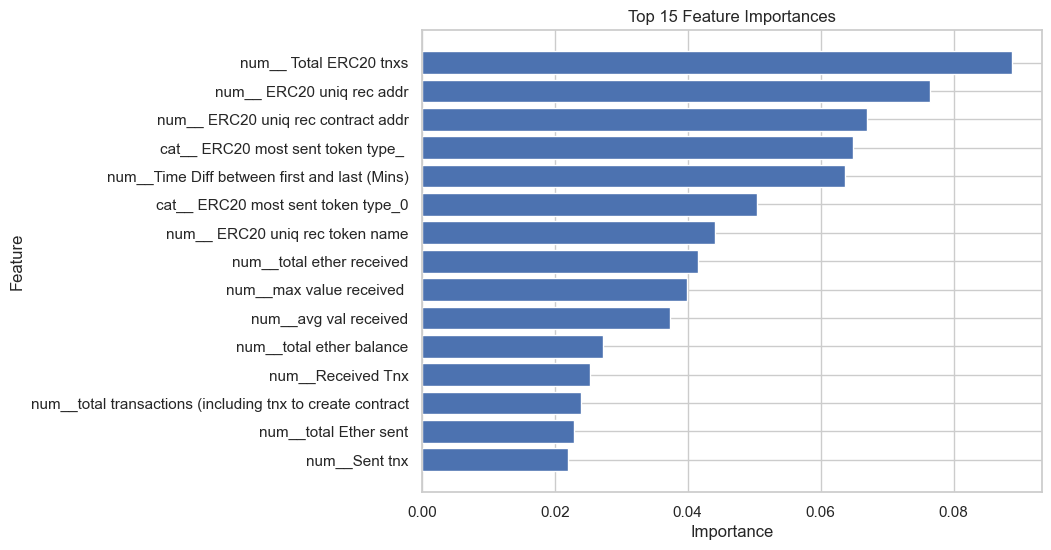

In [35]:
# Plot top feature importances
top_n = 15
top_features = feat_imp_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Text(0.5, 1.0, 'Top 15 Feature Importances')

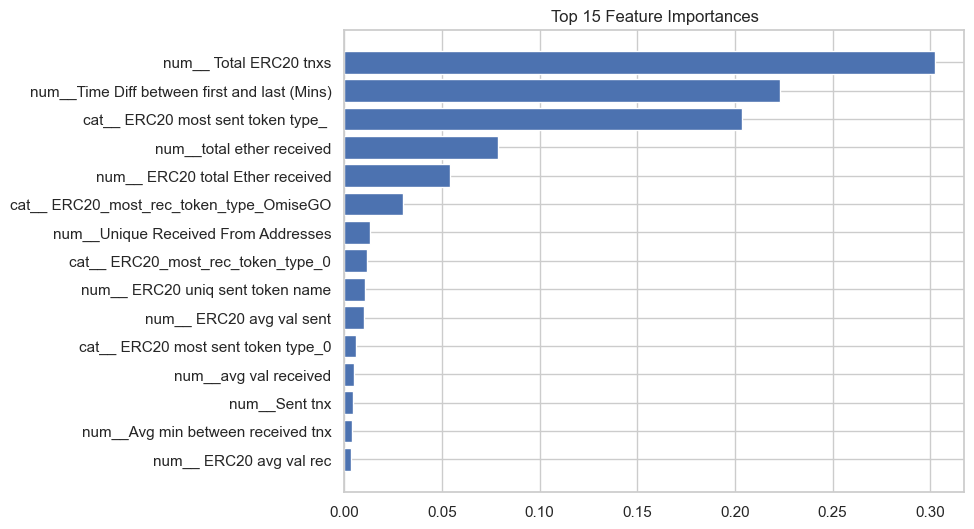

In [38]:
# top 15 feature importance from gradient boosting
top_n = 15
top_features = feat_imp_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")

## Summary

**Model Performance**  
On the held-out test set, the tuned Random Forest performed **very well overall**. Accuracy looks strong, but more importantly for fraud work, **recall on the fraud class** (catching actual fraud) and **Cohen’s kappa** (agreement beyond guessing the common “legitimate” label) show the model is doing more than simply predicting the majority class. **ROC-AUC** being high means the model generally ranks fraudulent addresses higher than legitimate ones when it outputs risk scores. Exact numbers appear in the classification report and confusion matrix cells above; the key message is: **the tool is useful as a screening aid**, not as proof of guilt.

**Predicting Classes**  
**Legitimate wallets (the majority)** are easier to get right, because there are many more examples in the data and their behavior is more “typical.” **Fraud (the minority)** is harder: there are fewer training examples, and fraud patterns can be subtle or mixed with normal activity. That is why the notebook uses **training-only oversampling** for fraud and tunes the model using **F1 focused on the fraud class**—so we do not only optimize “overall accuracy,” which can hide poor fraud detection.

**Feature Importance**  
Feature importance (and the grouped view that sums one-hot pieces back to the original column names) highlights **wallet-level behavior**: how often the address sends and receives, **how long it has been active**, **Ether amounts** (sent, received, highs and averages), and **ERC-20 activity** (counts, uniqueness of counterparties or tokens). Interpreting importance as **“what the model relied on most”** is fair; it does **not** prove those features *cause* fraud. Domain experts should still review flagged cases.

**Mistakes of the model**  
Two main error types show up in the confusion matrix:  
- **False positives**: the model flags a **legitimate** address as fraud. That creates extra review work and can annoy users if treated like a final verdict. This is still better than the alternative, which is missing fraud.
- **False negatives**: the model calls a **fraudulent** address legitimate. That is often the costliest mistake in risk terms, because fraud may be missed.  

**How could this be used?**  
A practical use is **prioritization**: exchanges, compliance teams, or security groups run new or existing addresses through the model to get a **fraud risk ranking**, then **investigate the highest-risk cases first**. It can support **alerting**, **enhanced due diligence**, or **internal monitoring**—always alongside rules, expert review, and legal constraints. The model should **not** automatically freeze accounts or label someone a criminal without a defined process.

**Things to improve**  
- **Validate on fresher or external data** so we know performance holds as Ethereum behavior changes.  
- **Track the business impact** of false positives vs false negatives and tune thresholds accordingly.   
- **Monitoring and retraining** as fraud patterns evolve.  
- **Fairness and governance**: clear policies for how alerts are used and documented.


# Save model for deployment


In [ ]:
import joblib

# Save tuned pipelines for reuse
rf_path = 'ethereum_fraud_rf_model.pkl'
gbm_path = 'ethereum_fraud_gbm_model.pkl'
joblib.dump(best_rf, rf_path)
joblib.dump(best_gbm, gbm_path)
print(f'Random Forest saved to: {rf_path}')
print(f'Gradient Boosting saved to: {gbm_path}')


Model saved to: ethereum_fraud_rf_model.pkl
